# Mestrado em Inteligência Artificial 25/26

# Practical 3 — Dynamic Programming (Jack’s Car Rental)
## Policy Evaluation, Policy Improvement, Policy Iteration, Value Iteration


| Problem | Bellman equation (operator) | Algorithm in this notebook |
|---|---|---|
| **Prediction** | Bellman **Expectation** | Iterative Policy Evaluation |
| **Control** | B. **Expectation** + **Greedy improvement** | Policy Iteration |
| **Control** | Bellman **Optimality** | Value Iteration |

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

np.set_printoptions(precision=3, suppress=True)

import numpy as np
from dataclasses import dataclass
from typing import Tuple, Dict, List

## 1) Car Rental MDP

State:  
- \(s = (n_1, n_2)\): number of cars at location 1 and 2 **at end of day**.

Action:  
- \(a in {-2,-1,0,1,2\}\): cars moved **overnight** from loc 1 → loc 2 (negative means opposite).

Dynamics (stochastic):  
- Requests and returns are independent Poisson random variables.

Reward:  
- rental revenue − moving cost  
- revenue = 10 per rented car  
- cost = 2 per moved car

# Car Rental MDP

### Config

In [5]:
@dataclass(frozen=True)
class CarRentalParams:
    max_cars_1: int = 20
    max_cars_2: int = 20
    max_moveable: int = 5 # so se podem meover 5 carros por noite
    revenue_per_rental: float = 10.0 # receita por carro alugado
    cost_per_moved: float = 2.0 # custo por carro movido
    # lambdas: (req1, req2, ret1, ret2)
    lambdas: Tuple[float, float, float, float] = (3.0, 4.0, 3.0, 2.0) # lambda para requests e returns
    # truncation caps for Poisson r.v.s (last bucket is a tail bucket)
    max_requests_1: int = 8
    max_requests_2: int = 10
    max_returns_1: int = 8
    max_returns_2: int = 8

#soma dos carros alugados menos o custo de movimentação dos carros

## Poisson Distribution will be used, since:
*   Requests occur randomly
*   Average rate is roughly constant
*   Requests are independent
*   We are counting events per day

In [6]:
def poisson_pmf_truncated(lam: float, max_k: int) -> np.ndarray:
    """Return a Poisson(lam) pmf over k=0..max_k, where the last bucket includes the tail mass P(K>=max_k)."""
    probs = np.zeros(max_k + 1, dtype=float)
    # compute up to max_k-1 exactly (stable recurrence)
    p0 = np.exp(-lam)
    probs[0] = p0
    for k in range(1, max_k):
        probs[k] = probs[k - 1] * lam / k
    probs[max_k] = max(0.0, 1.0 - probs[:max_k].sum())
    # normalize tiny numerical error
    probs /= probs.sum()
    return probs

In [7]:
print(poisson_pmf_truncated(3,8))

[0.05  0.149 0.224 0.224 0.168 0.101 0.05  0.022 0.012]


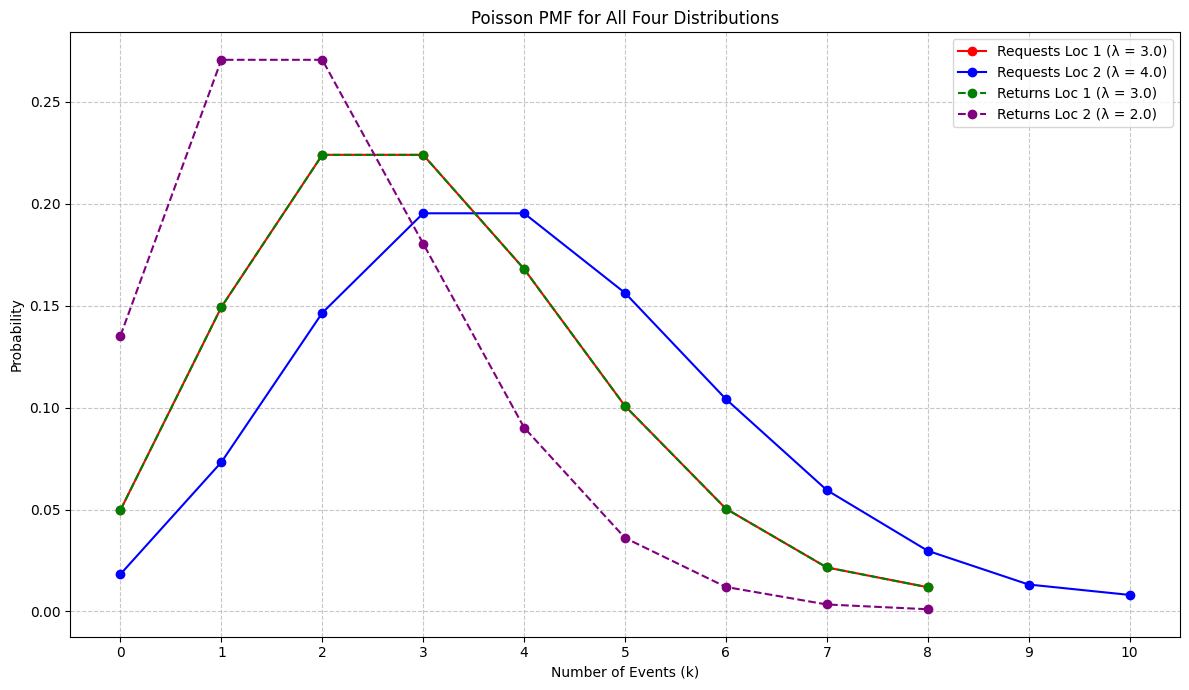

In [8]:
import matplotlib.pyplot as plt

# Plotting all four distributions on the same plot
params = CarRentalParams() # Instantiate CarRentalParams to get the lambda and max_k values

dists = [
    {'name': 'Requests Loc 1', 'lambda': params.lambdas[0], 'max_k': params.max_requests_1, 'color': 'red', 'ls': '-'},
    {'name': 'Requests Loc 2', 'lambda': params.lambdas[1], 'max_k': params.max_requests_2, 'color': 'blue', 'ls': '-'},
    {'name': 'Returns Loc 1',  'lambda': params.lambdas[2], 'max_k': params.max_returns_1,  'color': 'green', 'ls': '--'},
    {'name': 'Returns Loc 2',  'lambda': params.lambdas[3], 'max_k': params.max_returns_2,  'color': 'purple', 'ls': '--'},
]

plt.figure(figsize=(12, 7))

for dist_info in dists:
    lam = dist_info['lambda']
    max_k = dist_info['max_k']
    name = dist_info['name']
    color = dist_info['color']

    pmf = poisson_pmf_truncated(lam, max_k)
    k_values = np.arange(len(pmf))

    plt.plot(
        k_values,
        pmf,
        marker='o',
        linestyle=dist_info['ls'],
        color=color,
        label=f'{name} (λ = {lam})'
    )

plt.title('Poisson PMF for All Four Distributions')
plt.xlabel('Number of Events (k)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, max(d['max_k'] for d in dists) + 1))
plt.tight_layout()
plt.show()

### MDP

In [9]:
class CarRentalMDP:
    def __init__(self, params: CarRentalParams):
        self.params = params

        # Precompute truncated distributions (with tail bucket)
        self.req1 = poisson_pmf_truncated(params.lambdas[0], params.max_requests_1) #distribuição de probabilidade para os pedidos de aluguer no local 1
        self.req2 = poisson_pmf_truncated(params.lambdas[1], params.max_requests_2) #distribuição de probabilidade para os pedidos de aluguer no local 2
        self.ret1 = poisson_pmf_truncated(params.lambdas[2], params.max_returns_1) #distribuição de probabilidade para os retornos no local 1
        self.ret2 = poisson_pmf_truncated(params.lambdas[3], params.max_returns_2) #distribuição de probabilidade para os retornos no local 2

        # Cache location-wise outcome distributions:
        # key: (loc_id, cars_available_after_move) -> (p_next_cars, expected_rentals)
        self._loc_cache: Dict[Tuple[int, int], Tuple[np.ndarray, float]] = {}

    def states(self) -> List[Tuple[int, int]]: 
        return [(i, j) for i in range(self.params.max_cars_1 + 1) for j in range(self.params.max_cars_2 + 1)] #todos os estados possíveis (número de carros em cada local)

    def is_terminal(self, s: Tuple[int, int]) -> bool:
        # No terminal states in this continuing task
        return False #não há estados terminais, é contínuo

    # Nota: ações positivas -> mover de 1 para 2, ações negativas -> mover de 2 para 1
    def possible_actions(self, s: Tuple[int, int]) -> List[int]: 
        """Actions are bounded by max_moveable AND by available cars / capacity."""
        n1, n2 = s
        a_min = -min(self.params.max_moveable, n2, self.params.max_cars_1 - n1)  # move from 2->1 (negative)
        a_max =  min(self.params.max_moveable, n1, self.params.max_cars_2 - n2)  # move from 1->2 (positive)
        #                 max cap in loc  | cars in loc  |  capacity in other loc
        return list(range(a_min, a_max + 1))

    def _loc_outcomes(self, loc_id: int, cars_after_move: int) -> Tuple[np.ndarray, float]:
        """For one location, return:
        - p_next: distribution over next cars p_next[c] = P(next_cars = c)
        - exp_rented: expected number of cars rented during the day, i.e.
            exp_rented = E[min(cars_after_move, requests)]
          where requests ~ Poisson(λ_requests) (truncated with a tail bucket).
          Notes:
          - exp_rented is an expectation (can be non-integer).
          - exp_rented is computed *before* applying returns, because returns happen after rentals.
          - exp_rented is NOT revenue; revenue is computed later as exp_rented * revenue_per_rental.

        given cars available after the move (start of the day).

        ---------------------------------------------------------
        Example interpretation of p_next:

        Suppose:
            cap = 3
            cars_after_move = 2

        Then p_next might look like:
            p_next = [0.1, 0.3, 0.4, 0.2]

        Meaning:
            P(next_cars = 0) = 0.1
            P(next_cars = 1) = 0.3
            P(next_cars = 2) = 0.4
            P(next_cars = 3) = 0.2

        These probabilities come from:
            - random rental requests (Poisson)
            - random returns (Poisson)
            - capacity cap at 'cap'
        ---------------------------------------------------------
        """
        key = (loc_id, cars_after_move)
        if key in self._loc_cache:
            return self._loc_cache[key]

        if loc_id == 1:
            req = self.req1
            ret = self.ret1
            cap = self.params.max_cars_1
        else:
            req = self.req2
            ret = self.ret2
            cap = self.params.max_cars_2

        p_next = np.zeros(cap + 1, dtype=float)
        exp_rented = 0.0

        # For each request count -> determine rentals and cars remaining before returns
        for k_req, p_req in enumerate(req): #k_req -> number of req, p_req -> probability
            rented = min(cars_after_move, k_req)
            exp_rented += p_req * rented
            cars_left = cars_after_move - rented

            # For each returns count -> next cars (with capacity cap)
            for k_ret, p_ret in enumerate(ret):
                next_cars = min(cap, cars_left + k_ret)
                p_next[next_cars] += p_req * p_ret

        # normalize tiny numeric error
        p_next /= p_next.sum()

        self._loc_cache[key] = (p_next, exp_rented)
        return p_next, exp_rented

    def after_move(self, s: Tuple[int, int], a: int) -> Tuple[int, int]:
        n1, n2 = s
        return (n1 - a, n2 + a)

    def expected_transition(self, s: Tuple[int, int], a: int) -> Tuple[np.ndarray, np.ndarray, float]:
        """Return:
        - p_next_1: dist over next n1'
        - p_next_2: dist over next n2'
        - expected_revenue (from rentals only, not move cost)
        """
        if a not in self.possible_actions(s):
            raise ValueError("Illegal action")

        n1m, n2m = self.after_move(s, a)
        p_next_1, e_rent1 = self._loc_outcomes(1, n1m)
        p_next_2, e_rent2 = self._loc_outcomes(2, n2m)

        exp_revenue = (e_rent1 + e_rent2) * self.params.revenue_per_rental
        return p_next_1, p_next_2, exp_revenue

In [10]:
mdp = CarRentalMDP(CarRentalParams())
states = mdp.states()

for i in range(mdp.params.max_cars_1 + 1):
    row = [(i, j) for j in range(mdp.params.max_cars_2 + 1)]
    print(row)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20)]
[(1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20)]
[(2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19), (2, 20)]
[(3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20)]
[(4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15), (4, 16), (4, 17), (4, 18), (4, 19), (4, 20)]
[(5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (

In [11]:
mdp.req1 # requests 1

array([0.05 , 0.149, 0.224, 0.224, 0.168, 0.101, 0.05 , 0.022, 0.012])

## 2) One-step expected return backup

For any \(V\), define:

$ q(s,a) = \mathbb{E}[ R(s,a,s') + \gamma V(s') ]$

We compute it using the model:
- expected rental revenue (expected return)
- moving cost
- expected next value under the transition distribution

In [12]:
def q_from_v(mdp: CarRentalMDP, V: np.ndarray, s: Tuple[int,int], a: int, gamma: float) -> float:
    """Compute q(s,a) = E[ reward + gamma * V(s') ] under the model."""
    # TODO (A): implement expected return.
    # Steps:
    # 1) Get p1(n1'), p2(n2') and expected revenue from mdp.expected_transition(s,a)
    # 2) Expected next value = sum_{n1',n2'} p1[n1']*p2[n2']*V[n1',n2']
    #   a) we need to check possible outcumes for one location, and on each outcome, check all outcomes for the other location
    # 3) Moving cost = cost_per_moved * |a|
    # 4) q = reward + gamma * expected_next_value
    #
    # --- Your Code ---
    p_next_1, p_next_2, exp_revenue = mdp.expected_transition(s, a)
    exp_next = 0.0
    for n1p,p1v in enumerate(p_next_1): #try all possible outcomes for location 1
        if p1v == 0.0:
            continue
        for n2p,p2v in enumerate(p_next_2): #try all possible outcomes for location 2
            if p2v == 0.0:
                continue
            exp_next += p1v * p2v * V[n1p, n2p] #probabilidade de chegar ao estado (n1p,n2p) vezes o valor desse estado
            
    move_cost = mdp.params.cost_per_moved * abs(a) #custo de mover os carros, depende do número de carros movidos (a) e do custo por carro movido
    reward = exp_revenue - move_cost #receita esperada dos alugueres menos o custo de movimentação dos carros
    #------------------

    return reward + gamma * exp_next

q_from_v(mdp, np.zeros((mdp.params.max_cars_1 + 1, mdp.params.max_cars_2 + 1)), (2,3), 1, 0.9)

np.float64(39.68745672379478)

In [13]:
def bellman_expectation_backup_v(
    mdp: CarRentalMDP,
    V: np.ndarray,
    s: Tuple[int, int],
    policy: Dict[Tuple[int, int], int],
    gamma: float,
) -> float:
    a = policy[s]
    return q_from_v(mdp, V, s, a, gamma)


def bellman_optimality_backup_v(
    mdp: CarRentalMDP,
    V: np.ndarray,
    s: Tuple[int, int],
    gamma: float,
) -> float:
    best = -float("inf")
    for a in mdp.possible_actions(s):
        best = max(best, q_from_v(mdp, V, s, a, gamma))
    return best


## 3) Iterative Policy Evaluation

Given a **deterministic** policy $(\pi(s)\in\mathcal{A}(s))$, update:

$V(s) \leftarrow q(s, \pi(s))$

until change is smaller than `theta`.

In [14]:
def zeros_V(mdp: CarRentalMDP) -> np.ndarray:
    return np.zeros((mdp.params.max_cars_1 + 1, mdp.params.max_cars_2 + 1), dtype=float)

def policy_evaluation(
    mdp: CarRentalMDP,
    policy: Dict[Tuple[int,int], int],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    V = zeros_V(mdp)

    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()

        # TODO (B): sweep all states and update V with the current policy action.
        # Use: delta = max(delta, |V_new - V_old|). Stop if delta < theta.
        #
        # --- Your Code ---
        for s in mdp.states():
            v_new = bellman_expectation_backup_v(mdp, V_old, s, policy, gamma) #calcula o novo valor do estado s usando a política atual
            delta = max(delta, abs(v_new - V_old[s[0], s[1]])) #atualiza o delta com a diferença entre o novo valor e o valor antigo do estado s
            V[s[0], s[1]] = v_new #atualiza o valor do estado s com o novo valor calculado
        if delta < theta:
            return V, it + 1
        #------------------

    return V, max_iters

policy_evaluation(mdp, {(i,j): 0 for i in range(mdp.params.max_cars_1 + 1) for j in range(mdp.params.max_cars_2 + 1)}, 0.9)

(array([[407.006, 416.98 , 426.846, 436.477, 445.761, 454.631, 463.076,
         471.108, 478.752, 486.029, 492.957, 499.548, 505.825, 511.797,
         517.477, 522.873, 527.983, 532.794, 537.267, 541.326, 544.863],
        [416.826, 426.8  , 436.665, 446.297, 455.58 , 464.451, 472.895,
         480.928, 488.572, 495.848, 502.777, 509.368, 515.644, 521.617,
         527.297, 532.693, 537.803, 542.614, 547.087, 551.146, 554.683],
        [426.06 , 436.034, 445.899, 455.531, 464.814, 473.685, 482.129,
         490.162, 497.805, 505.082, 512.01 , 518.602, 524.878, 530.851,
         536.531, 541.926, 547.037, 551.848, 556.321, 560.38 , 563.916],
        [434.303, 444.277, 454.143, 463.774, 473.058, 481.928, 490.373,
         498.405, 506.049, 513.326, 520.254, 526.845, 533.122, 539.094,
         544.774, 550.17 , 555.28 , 560.091, 564.564, 568.623, 572.16 ],
        [441.362, 451.336, 461.202, 470.833, 480.117, 488.988, 497.432,
         505.464, 513.108, 520.385, 527.313, 533.905, 540.18

## 4) Greedy Policy Improvement

Given a value function \(V\), compute a greedy policy:

$\pi'(s) = \arg\max_{a \in \mathcal{A}(s)} q(s,a)$

In [15]:
def policy_improvement(
    mdp: CarRentalMDP,
    V: np.ndarray,
    old_policy: Optional[Dict[Tuple[int,int], int]],
    gamma: float,
) -> Tuple[Dict[Tuple[int,int], int], bool]:
    new_policy: Dict[Tuple[int,int], int] = {}
    stable = True

    for s in mdp.states():
        # TODO (C): choose the greedy action using q_from_v().
        # 1) loop actions
        # 2) pick argmax q(s,a)
        # 3) compare to old_policy[s] (if provided) to set stable=False if changed
        #
        # --- SOLUTION ---
        # --- Your Code ---
        best_q = -float("inf")
        best_a = None
        for a in mdp.possible_actions(s):
            q=q_from_v(mdp, V, s, a, gamma) #calcula o valor de q para a ação a no estado s usando a função q_from_v
    
            if q > best_q:
                best_q = q
                best_a = a
        new_policy[s] = best_a

        if old_policy is not None and old_policy.get(s) != best_a:
            stable = False
        if old_policy is None:
            stable = False
        #------------------

    return new_policy, stable

## 5) Policy Iteration

Repeat:
1) Policy evaluation → get $(V^\pi)$
2) Policy improvement → get improved $(\pi')$

Stop when the policy is stable.

In [16]:
def policy_iteration(
    mdp: CarRentalMDP,
    gamma: float = 0.9,
    theta: float = 1e-6,
    max_outer: int = 50,
):
    # Initialize with a simple policy: always move 0 cars
    policy = {s: 0 for s in mdp.states()}
    history = []

    for outer in range(max_outer):
        # TODO (D): Implement policy iteration loop.
        #
        # --- SOLUTION ---
        # --- Your Code ---
        V, iters = policy_evaluation(mdp, policy, gamma, theta) #avalia a política atual para obter os valores dos estados
        new_policy, stable = policy_improvement(mdp, V, policy, gamma) #melhora a política atual usando os valores dos estados
        history.append((V.copy(), new_policy.copy())) #armazena o histórico de valores
        policy = new_policy #atualiza a política atual para a nova política obtida
        if stable:
            break
        #------------------

    return V, policy, history

## 6) Value Iteration

Bellman optimality update:

$V(s) \leftarrow \max_{a \in \mathcal{A}(s)} q(s,a)$

Then extract greedy policy from \(V\).

In [17]:
def value_iteration(
    mdp: CarRentalMDP,
    gamma: float = 0.9,
    theta: float = 1e-6,
    max_iters: int = 10_000,
):
    V = zeros_V(mdp)

    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()

        # TODO (E): Bellman optimality backup for each state.
        # v_new = ...
        #
        # --- SOLUTION ---
        # --- Your Code ---
        for s in mdp.states():
            v_new = bellman_optimality_backup_v(mdp, V_old, s, gamma) #calcula o novo valor do estado s usando o backup de otimalidade de Bellman
            delta = max(delta, abs(v_new - V_old[s[0], s[1]])) #atualiza o delta com a diferença entre o novo valor e o valor antigo do estado s
            V[s[0], s[1]] = v_new #atualiza o valor do estado s com o novo valor calculado
        if delta < theta:
            break
        #------------------

    # derive greedy policy from the FINAL V (use V, not V_old)
    pi = {}
    for s in mdp.states():
        best_a = None
        best_q = -np.inf
        for a in mdp.possible_actions(s):
            q = q_from_v(mdp, V, s, a, gamma)
            if q > best_q:
                best_q = q
                best_a = a
        pi[s] = best_a

    return V, pi, it + 1

## 7) Plotting utilities

- Policy heatmap: action values (cars moved 1→2)
- Value heatmap: state values

In [18]:
def policy_to_array(mdp: CarRentalMDP, policy: Dict[Tuple[int,int], int]) -> np.ndarray:
    arr = np.zeros((mdp.params.max_cars_1 + 1, mdp.params.max_cars_2 + 1), dtype=int)
    for (n1, n2), a in policy.items():
        arr[n1, n2] = a
    return arr

def plot_policy(mdp: CarRentalMDP, policy: Dict[Tuple[int,int], int], title: str = ""):
    arr = policy_to_array(mdp, policy)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(arr, origin="lower")
    ax.set_title(title)
    ax.set_xlabel("# cars at location 2")
    ax.set_ylabel("# cars at location 1")

    # annotate
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, str(arr[i,j]), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, shrink=0.85)
    plt.show()

def plot_values(mdp: CarRentalMDP, V: np.ndarray, title: str = ""):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(V, origin="lower")
    ax.set_title(title)
    ax.set_xlabel("# cars at location 2")
    ax.set_ylabel("# cars at location 1")
    fig.colorbar(im, ax=ax, shrink=0.85)
    plt.show()

## 8) Run experiments

We’ll compare:
- Policy Iteration (PI)
- Value Iteration (VI)

You should see similar optimal policies (maybe identical under these small settings).

Policy Iteration outer loops: 5


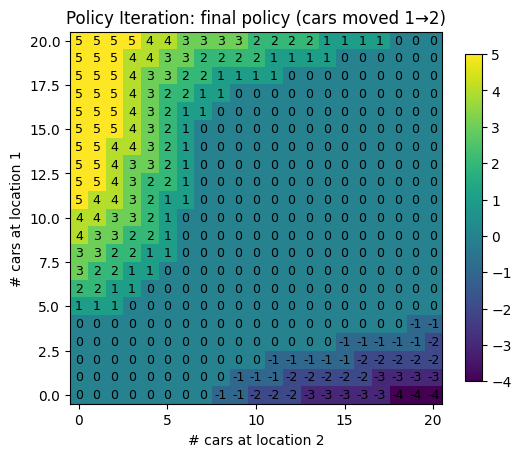

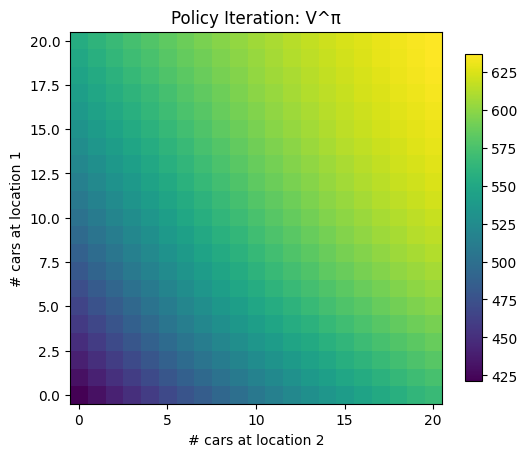

Value Iteration iterations: 126


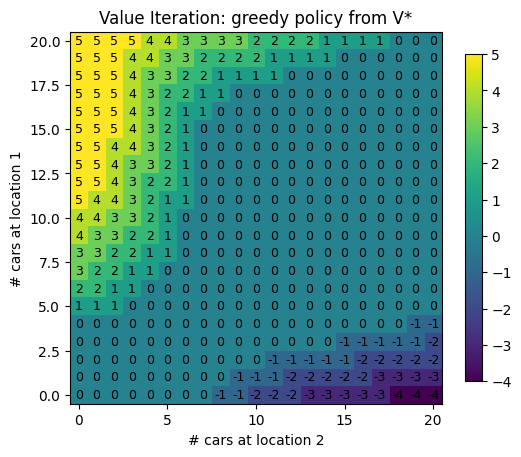

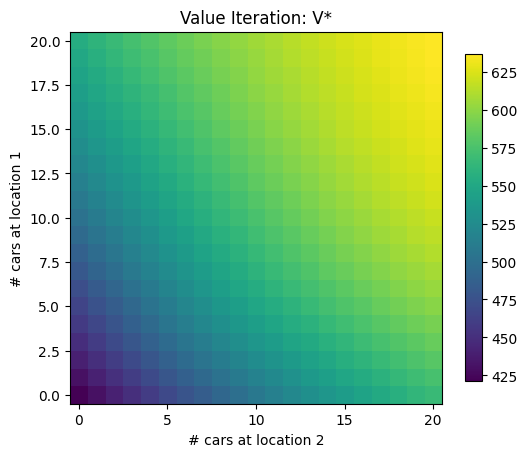

In [19]:
mdp = CarRentalMDP(params)
gamma = 0.9

# Policy Iteration
V_pi, pi_pi, hist = policy_iteration(mdp, gamma=gamma, theta=1e-4, max_outer=20)
print("Policy Iteration outer loops:", len(hist))

plot_policy(mdp, pi_pi, title="Policy Iteration: final policy (cars moved 1→2)")
plot_values(mdp, V_pi, title="Policy Iteration: V^π")

# Value Iteration
V_vi, pi_vi, it_vi = value_iteration(mdp, gamma=gamma, theta=1e-4)
print("Value Iteration iterations:", it_vi)

plot_policy(mdp, pi_vi, title="Value Iteration: greedy policy from V*")
plot_values(mdp, V_vi, title="Value Iteration: V*")